# GeoGuessr Country Classifier — DSCI 410 Project
Predicts which country a Google Street View image is from using a CNN trained on the Kaggle Geolocation dataset.

In [1]:
%pip install torchinfo kagglehub --quiet
%pip install torchinfo kagglehub scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:

import os
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchinfo import summary
import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer as timer
import kagglehub
from tqdm import tqdm
from timeit import default_timer as timer

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

In [3]:
# Downloads ~50k street-view images organized as: images/<country>/<file>.jpg
path = kagglehub.dataset_download("ubitquitin/geolocation-geoguessr-images-50k")
print("Dataset path:", path)

# Download additional dataset
path2 = kagglehub.dataset_download("amaralibey/gsv-cities")
print("GSV Cities path:", path2)
print("Contents:", os.listdir(path2)[:10])

# The dataset root — images are in a subfolder called 'images'
# Adjust this if your local layout is different
DATA_ROOT = os.path.join(path, "compressed_dataset")
print("Contents:", os.listdir(DATA_ROOT)[:10], "...")
print("Total folders:", len(os.listdir(DATA_ROOT)))

Dataset path: /home/rkoozer/.cache/kagglehub/datasets/ubitquitin/geolocation-geoguessr-images-50k/versions/1
GSV Cities path: /home/rkoozer/.cache/kagglehub/datasets/amaralibey/gsv-cities/versions/1
Contents: ['Dataframes', 'Images']
Contents: ['Singapore', 'Laos', 'Jordan', 'France', 'Venezuela', 'Slovakia', 'Japan', 'Pakistan', 'Nigeria', 'Reunion'] ...
Total folders: 124


In [4]:
from collections import defaultdict, Counter

IMG_SIZE   = 224
BATCH_SIZE = 256
VALID_FRAC = 0.15
TEST_FRAC  = 0.15
MIN_IMAGES = 100
MAX_IMAGES = 2000

import glob
from PIL import Image

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    #transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
    #transforms.RandomErasing(p=0.1),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ── Dataset 1: Original Kaggle dataset ───────────────────────────────────────
full_train_dataset = datasets.ImageFolder(root=DATA_ROOT, transform=train_transform)
all_classes        = full_train_dataset.classes
label_counts       = Counter(full_train_dataset.targets)
valid_classes      = {idx for idx, count in label_counts.items() if count >= MIN_IMAGES}

print(f"Original dataset: {len(full_train_dataset)} images, {len(all_classes)} countries")
print(f"After dropping < {MIN_IMAGES} images: {len(valid_classes)} countries")

# ── Dataset 2: GSV Cities ─────────────────────────────────────────────────────
GSV_PATH = "/home/rkoozer/.cache/kagglehub/datasets/amaralibey/gsv-cities/versions/1/Images"

CITY_TO_COUNTRY = {
    'Bangkok':      'Thailand',
    'Barcelona':    'Spain',
    'Boston':       'United States',
    'Brussels':     'Belgium',
    'BuenosAires':  'Argentina',
    'Chicago':      'United States',
    'Lisbon':       'Portugal',
    'London':       'United Kingdom',
    'LosAngeles':   'United States',
    'Madrid':       'Spain',
    'Medellin':     'Colombia',
    'Melbourne':    'Australia',
    'MexicoCity':   'Mexico',
    'Miami':        'United States',
    'Minneapolis':  'United States',
    'OSL':          'Norway',
    'Osaka':        'Japan',
    'PRG':          'Czech Republic',
    'PRS':          'France',
    'Phoenix':      'United States',
    'Rome':         'Italy',
    'TRT':          'Turkey',
    'WashingtonDC': 'United States',
}

gsv_samples = []
for city, country in CITY_TO_COUNTRY.items():
    city_folder = os.path.join(GSV_PATH, city)
    if os.path.exists(city_folder):
        for img_path in glob.glob(os.path.join(city_folder, "*.jpg")):
            gsv_samples.append((img_path, country))

np.random.shuffle(gsv_samples)
print(f"GSV dataset: {len(gsv_samples)} images across {len(set(c for _,c in gsv_samples))} countries")

# ── Build merged sample list (image_path, country_name) ──────────────────────
# Start with original dataset samples
all_country_names = sorted(
    set(all_classes[i] for i in valid_classes) | set(CITY_TO_COUNTRY.values())
)
country_to_idx = {name: idx for idx, name in enumerate(all_country_names)}
classes        = all_country_names
num_classes    = len(classes)
print(f"Total countries in merged dataset: {num_classes}")

# Add original dataset samples up to MAX_IMAGES per country
country_seen = defaultdict(int)
all_samples  = []

for idx, (img_path, label) in enumerate(full_train_dataset.samples):
    country_name = all_classes[label]
    if label in valid_classes and country_seen[country_name] < MAX_IMAGES:
        all_samples.append((img_path, country_to_idx[country_name]))
        country_seen[country_name] += 1

print(f"Samples from original dataset: {len(all_samples)}")

# Add GSV samples up to MAX_IMAGES per country total
for img_path, country_name in gsv_samples:
    if country_seen[country_name] < MAX_IMAGES:
        all_samples.append((img_path, country_to_idx[country_name]))
        country_seen[country_name] += 1

print(f"Total samples after merge: {len(all_samples)}")
print(f"\nTop 10 countries by image count:")
final_counts = Counter([s[1] for s in all_samples])
for idx, count in sorted(final_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {classes[idx]:30s}  {count}")

# ── Custom dataset ────────────────────────────────────────────────────────────
class MergedGeoDataset(torch.utils.data.Dataset):
    def __init__(self, samples, transform):
        self.samples   = samples
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

# ── Train / Validation / Test split 
n       = len(all_samples)
indices = list(range(n))
np.random.shuffle(indices)

test_split  = int(np.floor(TEST_FRAC  * n))
valid_split = int(np.floor(VALID_FRAC * n))

test_idx  = indices[:test_split]
valid_idx = indices[test_split:test_split + valid_split]
train_idx = indices[test_split + valid_split:]

train_samples = [all_samples[i] for i in train_idx]
valid_samples = [all_samples[i] for i in valid_idx]
test_samples  = [all_samples[i] for i in test_idx]

train_dataset = MergedGeoDataset(train_samples, train_transform)
valid_dataset = MergedGeoDataset(valid_samples, eval_transform)
test_dataset  = MergedGeoDataset(test_samples,  eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=8, pin_memory=True, persistent_workers=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE,
                          shuffle=False,
                          num_workers=8, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,
                          num_workers=8, pin_memory=True, persistent_workers=True)

print(f"\nTrain samples: {len(train_samples)}")
print(f"Valid samples: {len(valid_samples)}")
print(f"Test  samples: {len(test_samples)}")

Original dataset: 49997 images, 124 countries
After dropping < 100 images: 56 countries
GSV dataset: 529506 images across 16 countries
Total countries in merged dataset: 57
Samples from original dataset: 33760
Total samples after merge: 50003

Top 10 countries by image count:
  Argentina                       2000
  Australia                       2000
  Belgium                         2000
  Brazil                          2000
  Colombia                        2000
  France                          2000
  Italy                           2000
  Japan                           2000
  Mexico                          2000
  Norway                          2000

Train samples: 35003
Valid samples: 7500
Test  samples: 7500


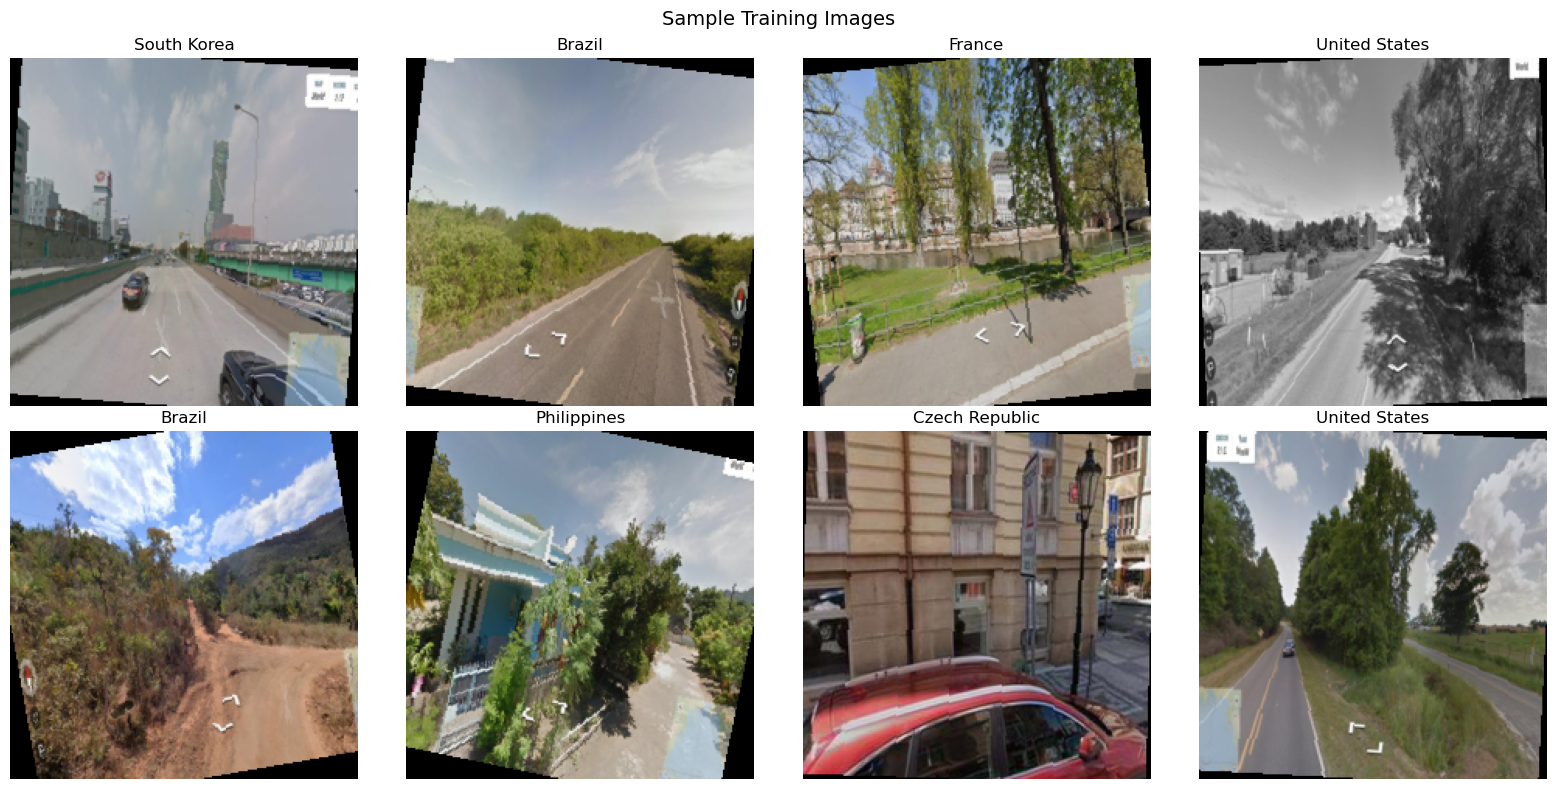

Image shape: torch.Size([256, 3, 224, 224])  (batch, channels, H, W)


In [5]:
#Visualize a batch
def imshow_rgb(img_tensor, title=None):
    """Un-normalize and display a tensor image."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img  = img_tensor * std + mean          # reverse normalize
    img  = img.clamp(0, 1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title: plt.title(title)
    plt.axis('off')

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    plt.sca(ax)
    imshow_rgb(images[i], title=classes[labels[i]])
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()
print(f"Image shape: {images.shape}  (batch, channels, H, W)")

In [6]:
class GeoConvModelV1(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.block1 = nn.Sequential(nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2))
        self.block2 = nn.Sequential(nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2))
        self.block3 = nn.Sequential(nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2))
        self.block4 = nn.Sequential(nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2, 2))
        self.block5 = nn.Sequential(nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2, 2))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 1024), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(1024, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        x = self.block1(x); x = self.block2(x); x = self.block3(x)
        x = self.block4(x); x = self.block5(x)
        return self.classifier(x)

GeoConvModel = GeoConvModelV1

In [7]:
def train_step(model, train_loader, loss_fn, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (torch.argmax(y_pred, dim=1) == y_batch).sum().item()
        total   += y_batch.size(0)
    return total_loss / len(train_loader), correct / total


def evaluation_step(model, data_loader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            correct += (torch.argmax(y_pred, dim=1) == y_batch).sum().item()
            total   += y_batch.size(0)
    return total_loss / len(data_loader), correct / total



In [8]:
def train_geo_model(train_loader, valid_loader, test_loader, random_seed=42):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")
    torch.manual_seed(random_seed)

    model = GeoConvModelV1(num_classes=num_classes).to(device)
    checkpoint = torch.load("geo_cnn_weights_v14_min100.pth", map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded v11 | continuing on {num_classes} countries")

    learning_rate = 0.00001
    num_epochs    = 60

    loss_fn   = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    train_losses, train_accs = [], []
    valid_losses, valid_accs = [], []
    test_losses,  test_accs  = [], []

    print(f"\nStarting training | epochs={num_epochs} | lr={learning_rate} | weight_decay=1e-4\n")
    start = timer()

    epoch_bar = tqdm(range(num_epochs), desc="Training")
    for epoch in epoch_bar:
        train_loss, train_acc = train_step(model, train_loader, loss_fn, optimizer, device)
        valid_loss, valid_acc = evaluation_step(model, valid_loader, loss_fn, device)
        test_loss,  test_acc  = evaluation_step(model, test_loader,  loss_fn, device)
        scheduler.step()

        train_losses.append(train_loss); train_accs.append(train_acc)
        valid_losses.append(valid_loss); valid_accs.append(valid_acc)
        test_losses.append(test_loss);   test_accs.append(test_acc)

        epoch_bar.set_postfix(
            tr_loss=f"{train_loss:.3f}",
            tr_acc=f"{train_acc:.3f}",
            val_acc=f"{valid_acc:.3f}"
        )

    elapsed = timer() - start
    print(f"\nTraining complete in {elapsed/60:.1f} min")
    print(f"Final Test Accuracy: {test_accs[-1]:.4f}")

    torch.save({
        'model_state_dict': model.state_dict(),
        'num_classes': num_classes,
        'classes': classes,
        'architecture': 'GeoConvModelV1',
        'accuracy': test_accs[-1],
        'epochs_trained': num_epochs,
    }, "geo_cnn_weights_v15_min100.pth")
    print("Model saved to geo_cnn_weights_v15_min100.pth")

    return model, train_losses, train_accs, valid_losses, valid_accs, test_losses, test_accs

In [9]:
model, train_losses, train_accs, valid_losses, valid_accs, test_losses, test_accs = \
    train_geo_model(train_loader, valid_loader, test_loader, random_seed)

Using device: cuda
Loaded v11 | continuing on 57 countries

Starting training | epochs=60 | lr=1e-05 | weight_decay=1e-4



Training: 100%|██████████| 60/60 [1:10:28<00:00, 70.48s/it, tr_acc=0.559, tr_loss=1.443, val_acc=0.550]


Training complete in 70.5 min
Final Test Accuracy: 0.5523
Model saved to geo_cnn_weights_v15_min100.pth


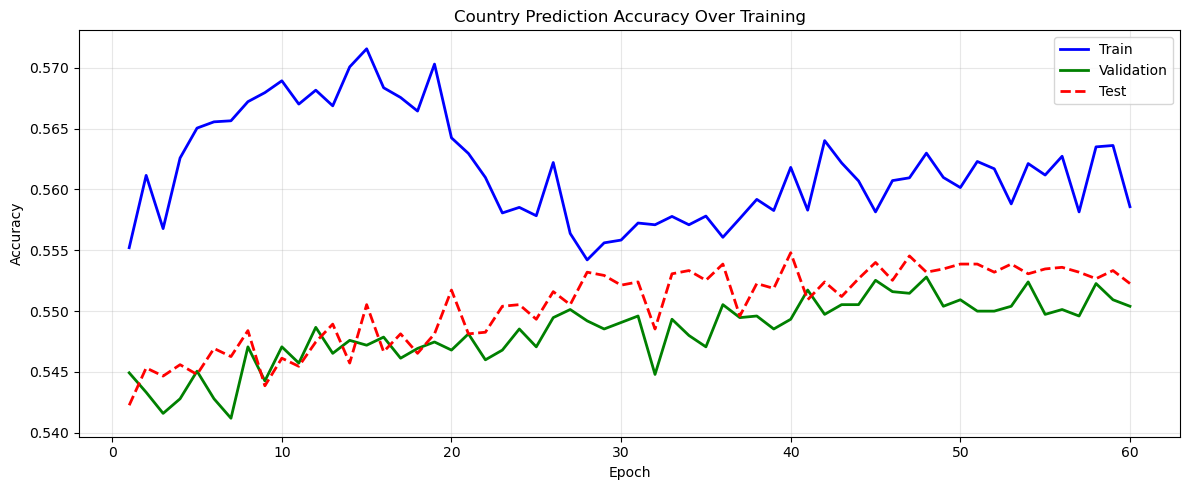

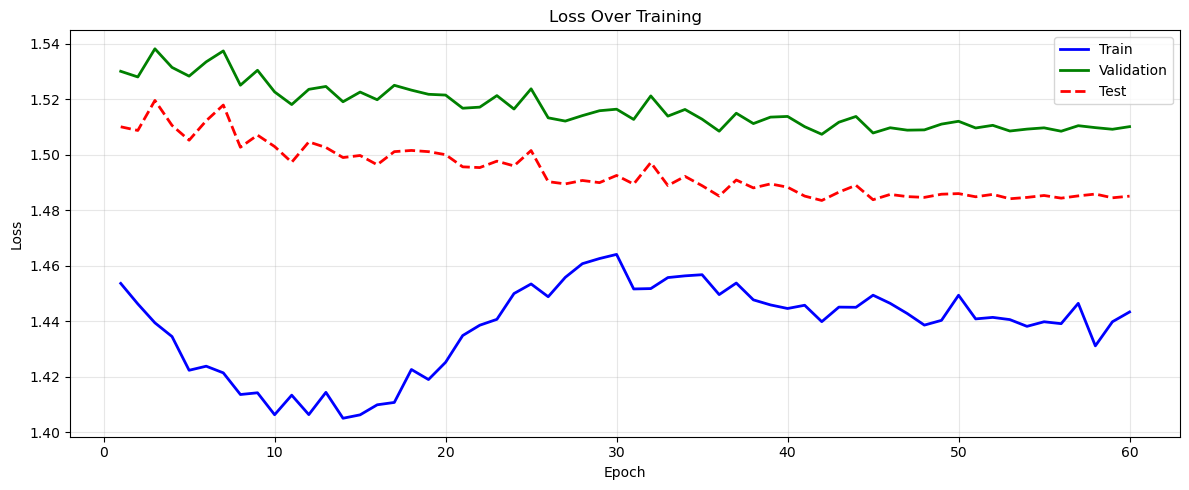

In [10]:
# ── Plot Accuracy  (mirrors your reference) ───────────────────────────────────
def plot_accuracy_performance(train_accs, valid_accs, test_accs):
    epochs = range(1, len(train_accs) + 1)
    plt.figure(figsize=(12, 5))
    plt.plot(epochs, train_accs, 'b-',  label='Train',      linewidth=2)
    plt.plot(epochs, valid_accs, 'g-',  label='Validation', linewidth=2)
    plt.plot(epochs, test_accs,  'r--', label='Test',       linewidth=2)
    plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.title('Country Prediction Accuracy Over Training')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ── Plot Loss  (mirrors your reference) ──────────────────────────────────────
def plot_loss_performance(train_losses, valid_losses, test_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))
    plt.plot(epochs, train_losses, 'b-',  label='Train',      linewidth=2)
    plt.plot(epochs, valid_losses, 'g-',  label='Validation', linewidth=2)
    plt.plot(epochs, test_losses,  'r--', label='Test',       linewidth=2)
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title('Loss Over Training')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

plot_accuracy_performance(train_accs, valid_accs, test_accs)
plot_loss_performance(train_losses, valid_losses, test_losses)

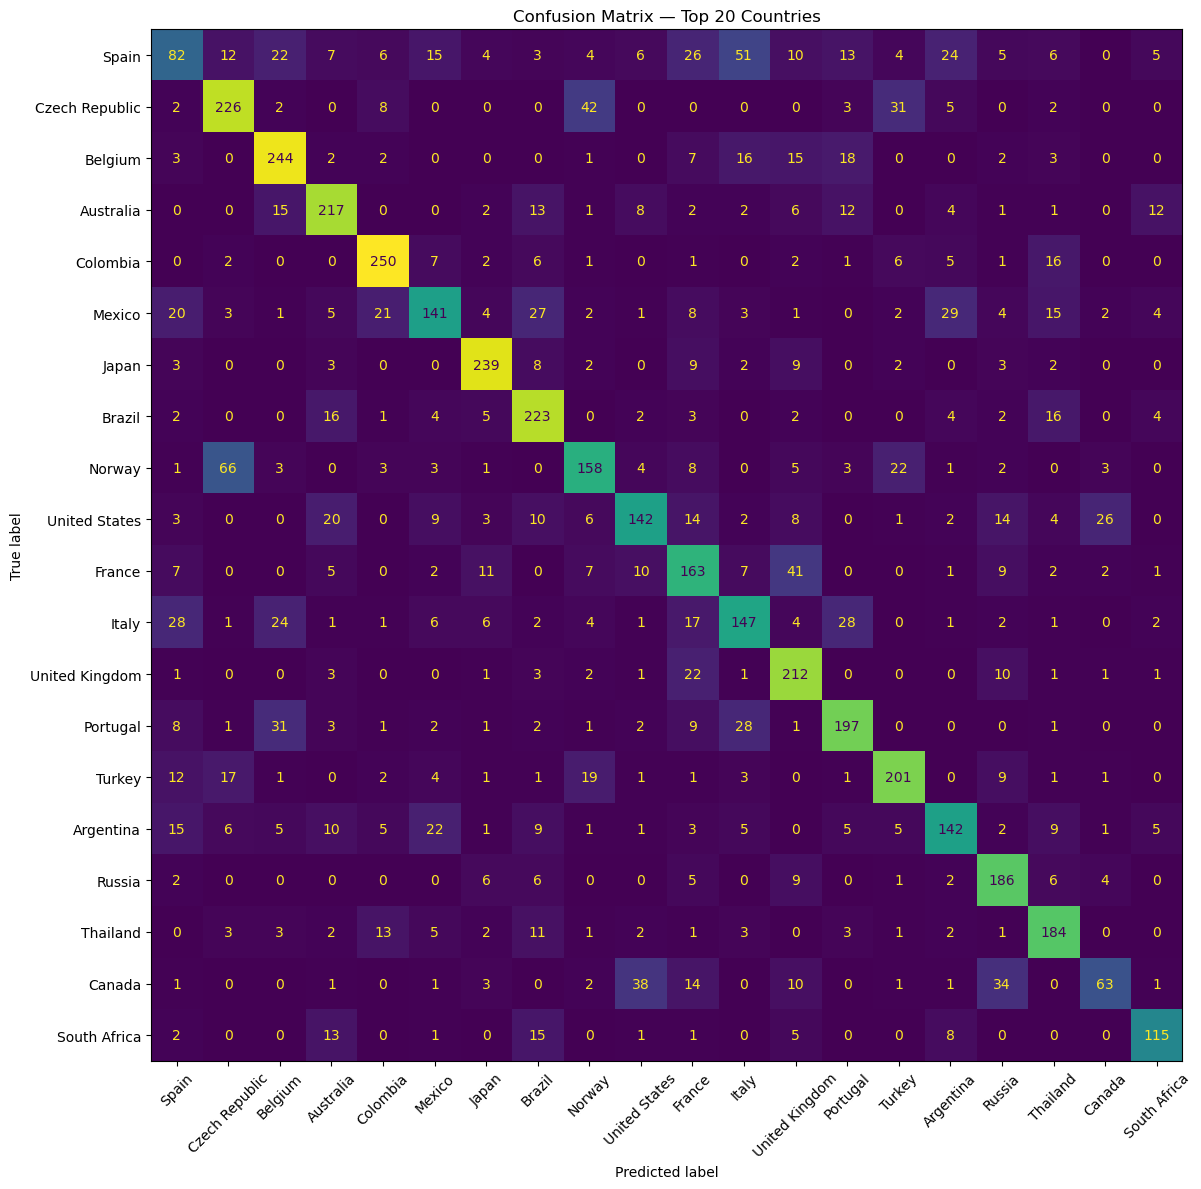

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = "cuda" if torch.cuda.is_available() else "cpu"

def plot_confusion_top_n(model, loader, classes, device, n=20):
    """Plot a confusion matrix for the N most common classes in the test set."""
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for X, y in loader:
            preds = torch.argmax(model(X.to(device)), dim=1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(y.tolist())

    from collections import Counter
    top_n = [idx for idx, _ in Counter(all_labels).most_common(n)]
    mask  = [i for i, l in enumerate(all_labels) if l in top_n]
    y_true = [all_labels[i] for i in mask]
    y_pred = [all_preds[i]  for i in mask]

    label_names = [classes[i] for i in top_n]
    cm = confusion_matrix(y_true, y_pred, labels=top_n)

    fig, ax = plt.subplots(figsize=(14, 12))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"Confusion Matrix — Top {n} Countries")
    plt.tight_layout()
    plt.show()

plot_confusion_top_n(model, test_loader, classes, device, n=20)